# Lab 2 — Luminus: arquitetura profunda do reconhecedor de dígitos (`CRNNDigitos`)

Notebook executado do zero (`Reiniciar e executar tudo`). Caminho das fotos configurável abaixo; as fotos
**não** vão para o repositório. Treinos longos (D3, L1, L2, L4) rodam por CLI e gravam JSON em `docs/figs/`;
o notebook os lê e os mostra, e recalcula o que é rápido (B, C4, D1, D2, E).

In [1]:
import json
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "lab-02" else Path.cwd()
os.chdir(ROOT)
FOTOS_DIR = Path(os.environ.get("LEITURISTA_FOTOS_DIR", ROOT / "data" / "distribuidora_campo"))  # configurável
import csv

import numpy as np
import torch
from PIL import Image

from leiturista import calib, paths
from leiturista.crnn import CRNNDigitos, load_crnn
from leiturista.distribuidora import split_by_lote
from leiturista.sanity import count_params, initial_loss, overfit_one_batch, shape_table

torch.set_num_threads(2)
FIGS = ROOT / "docs" / "figs"
LOTE = paths.DATA_DIR / "distribuidora_amr_lote"
def itens(split):
    return [(LOTE / r["image"], r["label"]) for r in csv.DictReader(open(LOTE / "labels.csv")) if r["split"] == split]

## B1 — tabela de formas (entrada real: recorte 1 × 32 × 128)

In [2]:
x = torch.zeros(1, 1, 32, 128)
print(f"{'camada':<12}{'saída':>22}")
for nome, forma in shape_table(CRNNDigitos(), x):
    print(f"{nome:<12}{str(forma):>22}")
print("\n(B, T, C): T = 32 passos de tempo (largura), C = 11 = 10 dígitos + branco da CTC")

camada                       saída
cnn.0              (1, 32, 16, 64)
cnn.1               (1, 64, 8, 32)
cnn.2              (1, 128, 4, 32)
cnn.3              (1, 128, 1, 32)
rnn                   (1, 32, 256)
saida                  (1, 32, 11)

(B, T, C): T = 32 passos de tempo (largura), C = 11 = 10 dígitos + branco da CTC


## B2 — parâmetros: extração × ajuste fino

In [3]:
m = CRNNDigitos()
for nome, congela in (("ajuste fino (tudo treinável)", False), ("extração (CNN congelada)", True)):
    tot, tr = count_params(m, congela)
    print(f"{nome:<32} total {tot:>9,}   treináveis {tr:>9,}   ({tr / tot:.0%})")

ajuste fino (tudo treinável)     total   441,931   treináveis   441,931   (100%)
extração (CNN congelada)         total   441,931   treináveis   200,971   (45%)


## B3 — ativação de saída e perda

**Cabeça única: `Linear(256 → 11)` por passo de tempo, sem softmax no modelo; perda `CTCLoss(blank=0)`.**
As classes **não** são exclusivas no nível da sequência (vários dígitos por recorte), mas são exclusivas
**por passo de tempo** (cada passo emite um símbolo: um dígito ou o branco): isso é um `softmax` sobre 11 símbolos,
aplicado como `log_softmax` dentro da perda (a CTC marginaliza todos os alinhamentos). Um `sigmoid` por dígito
(multirrótulo) não serve: não diria *onde* nem *quantas vezes* cada dígito aparece. Exemplo real da base que prova
a necessidade do branco: leituras com dígito repetido, onde sem o branco `55` colapsaria em `5`.

In [4]:
todos = [y for p, y in itens("train")] + [y for r in csv.DictReader(open(paths.FINETUNE_DIR / "labels.csv")) for y in [r["label"]]]
rep = [y for y in todos if any(a == b for a, b in zip(y, y[1:]))]
print(f"{len(rep)} de {len(todos)} leituras reais têm dígito repetido em sequência; exemplos:", rep[:8])

795 de 2547 leituras reais têm dígito repetido em sequência; exemplos: ['81999', '58117', '66672', '5599', '44248', '25586', '13885', '3855']


## C4 — partição POR LOTE e prova de ausência de vazamento

In [5]:
print(json.dumps(split_by_lote(paths.DATA_DIR / "distribuidora_amr", LOTE), indent=1))

{
 "n": {
  "train": 547,
  "valid": 264,
  "test": 280
 },
 "lotes": {
  "train": [
   "PSP_EXTRATLEITIMPL_200526_0352",
   "PSP_EXTRATLEITIMPL_210526_0335"
  ],
  "valid": [
   "PSP_EXTRATLEITIMPL_220526_0408"
  ],
  "test": [
   "PSP_EXTRATLEITIMPL_030726_0121"
  ]
 },
 "intersecao_medidor": {
  "train&valid": 0,
  "train&test": 0,
  "valid&test": 0
 },
 "intersecao_foto": {
  "train&valid": 0,
  "train&test": 0,
  "valid&test": 0
 },
 "intersecao_image": {
  "train&valid": 0,
  "train&test": 0,
  "valid&test": 0
 }
}


## C3 — kappa de Cohen (50 fotos em dupla, às cegas)

In [6]:
rotulos = ROOT / "lab-02" / "rotulos" / "rotulos.csv"
if rotulos.exists():
    from leiturista.rotulos import merge_and_kappa
    print(json.dumps(merge_and_kappa(), indent=1, ensure_ascii=False))
else:
    print("PENDENTE: rotulagem humana (C2/C3) ainda não concluída; `leiturista rotulos-kappa` calcula quando as planilhas chegarem.")

PENDENTE: rotulagem humana (C2/C3) ainda não concluída; `leiturista rotulos-kappa` calcula quando as planilhas chegarem.


## D1 — perda inicial com pesos aleatórios (lote REAL de 16 recortes)

In [7]:
treino = itens("train")[:16]
perda, ref = initial_loss(treino)
print(f"perda CTC inicial = {perda:.3f}; referência (saída uniforme sobre 11 símbolos) T·ln(11)/L = 32·ln(11)/L̄ = {ref:.3f}.")
print("A CTC soma sobre alinhamentos, então não há igualdade exata; estar na ordem de grandeza da referência é o esperado (≫ seria inicialização ruim).")

perda CTC inicial = 14.314; referência (saída uniforme sobre 11 símbolos) T·ln(11)/L = 32·ln(11)/L̄ = 17.052.
A CTC soma sobre alinhamentos, então não há igualdade exata; estar na ordem de grandeza da referência é o esperado (≫ seria inicialização ruim).


## D2 — sobreajuste de 16 recortes REAIS

In [8]:
d2 = overfit_one_batch(treino, steps=300)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in d2.items() if k not in ("lidos", "alvos")})
print("alvos:", d2["alvos"][:8], "\nlidos:", d2["lidos"][:8])
assert d2["perda_final"] < 0.1

{'perda_inicial': 14.3339, 'perda_final': 0.0043, 'acerto_exato': 1.0, 'n': 16}
alvos: ['81999', '29535', '85', '13087', '58117', '2014', '4523', '66672'] 
lidos: ['81999', '29535', '85', '13087', '58117', '2014', '4523', '66672']


## D3 — extração de características × baseline não profunda (3 sementes; `leiturista d3`)

In [9]:
d3 = json.load(open(FIGS / "d3_resultados.json"))
for k, v in d3["resumo"].items():
    print(k, {m: f"{s['media']:.3f} ± {s['desvio']:.3f}" for m, s in v.items() if m != "alpha"})

hog_linear {'valid_exact': '0.000 ± 0.000', 'test_exact': '0.000 ± 0.000'}
crnn_extracao {'valid_exact': '0.381 ± 0.009', 'test_exact': '0.376 ± 0.011'}


## E1/E2 — calibração (temperature scaling no VALID) e cobertura × risco (`leiturista calibrate-crnn`)

{
 "T": 3.75590154402975,
 "n_valid": 264,
 "n_test": 280,
 "acerto_test": 0.5214285714285715,
 "ece_test_antes": 0.4323135378105299,
 "ece_test_depois": 0.19303297666566713,
 "meta": {
  "cobertura_min": 0.6,
  "risco_max": 0.02
 },
 "cobertura_no_risco_alvo": 0.0035714285714285713,
 "limiar_no_risco_alvo": 0.7277106046676636,
 "cobertura_por_risco": {
  "risco<=0.02": 0.0035714285714285713,
  "risco<=0.05": 0.0035714285714285713,
  "risco<=0.10": 0.04285714285714286,
  "risco<=0.20": 0.3964285714285714
 },
 "risco_na_cobertura_alvo": 0.2678571428571429
}


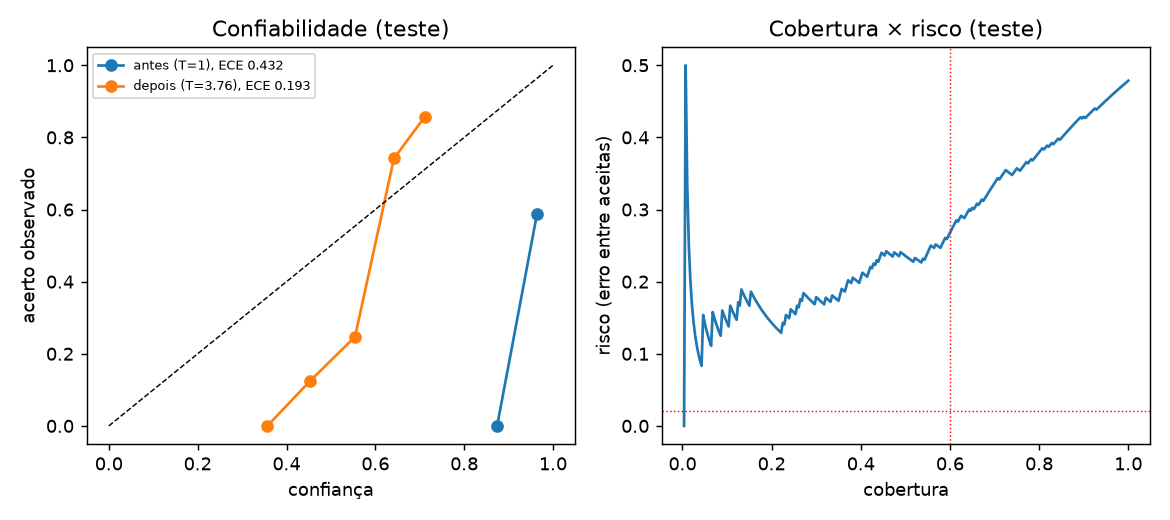

In [10]:
res = calib.run(paths.MODELS_DIR / "crnn_lote_ft.pt", LOTE)
print(json.dumps(res, indent=1))
from IPython.display import Image as _I, display
display(_I(filename=str(FIGS / "e1_e2_calibracao_cobertura_risco.png")))

## L1 — como cada família erra (`leiturista errors-l1`)

In [11]:
l1 = json.load(open(FIGS / "l1_erros.json"))
for fam, v in l1.items():
    if isinstance(v, dict):
        print(f"{fam}: acerto exato {v['acerto_exato']:.3f}, erros {v['erros']}, por tipo {v['por_tipo']}")
        for e in v["exemplos"]:
            print("   ", e)

PP-OCRv6 tiny (CRNN+CTC off-the-shelf): acerto exato 0.253, erros 112, por tipo {'trocou dígito': 35, 'inventou sequência': 67, 'duplicou dígito': 10}
    {'imagem': 'dist_1084_00005.png', 'verdade': '1084', 'leitura': '1089', 'tipo': 'trocou dígito'}
    {'imagem': 'dist_565730_00013.png', 'verdade': '565730', 'leitura': '555131', 'tipo': 'trocou dígito'}
    {'imagem': 'dist_2019_00025.png', 'verdade': '2019', 'leitura': '02019', 'tipo': 'inventou sequência'}
    {'imagem': 'dist_9371_00028.png', 'verdade': '9371', 'leitura': '09371', 'tipo': 'inventou sequência'}
    {'imagem': 'dist_2016_00033.png', 'verdade': '2016', 'leitura': '02019', 'tipo': 'inventou sequência'}
    {'imagem': 'dist_37154_00038.png', 'verdade': '37154', 'leitura': '39156', 'tipo': 'trocou dígito'}
    {'imagem': 'dist_36615_00042.png', 'verdade': '36615', 'leitura': '036615', 'tipo': 'inventou sequência'}
    {'imagem': 'dist_4643_00044.png', 'verdade': '4643', 'leitura': '04648', 'tipo': 'inventou sequência'}

## L2 — benchmark do cliente × UFPR-AMR (`leiturista l2`)

In [12]:
l2 = json.load(open(FIGS / "l2_gap_dominio.json"))
print("n:", l2["n"])
for k, v in l2["modelos"].items():
    print(f"{k:<50} cliente {v['cliente_test_por_lote']['leitura_exata']:.3f}/{v['cliente_test_por_lote']['acuracia_por_digito']:.3f}   "
          f"UFPR {v['ufpr_amr_test']['leitura_exata']:.3f}/{v['ufpr_amr_test']['acuracia_por_digito']:.3f}")

n: {'cliente_test_por_lote': 280, 'ufpr_amr_test': 300}
PP-OCRv6 tiny (off-the-shelf)                      cliente 0.261/0.746   UFPR 0.403/0.814
TrOCR-small (off-the-shelf)                        cliente 0.075/0.400   UFPR 0.373/0.785
CRNNDigitos só UFPR-AMR (zero-shot no cliente)     cliente 0.039/0.381   UFPR 0.873/0.945
CRNNDigitos fine-tunado no cliente (por lote)      cliente 0.521/0.823   UFPR 0.907/0.960


## L4 — latência por estágio (`scripts/latencia_por_estagio.py`)

In [13]:
l4 = json.load(open(FIGS / "l4_latencia.json"))
print("total:", {k: round(v, 2) for k, v in l4["total"].items()})
for k, v in l4["estagios"].items():
    print(f"{k:<24} média {v['media']:.2f}s  p50 {v['p50']:.2f}s  p90 {v['p90']:.2f}s  ({v['fracao_do_total']:.0%} do total)")

total: {'media': 4.01, 'p50': 1.67, 'p90': 11.17}
rotacao                  média 0.17s  p50 0.15s  p90 0.24s  (4% do total)
deteccao                 média 0.27s  p50 0.25s  p90 0.36s  (7% do total)
reconhecimento_ppocr     média 0.00s  p50 0.00s  p90 0.00s  (0% do total)
reconhecimento_trocr     média 3.72s  p50 1.33s  p90 10.83s  (93% do total)
recortes                 média 0.01s  p50 0.00s  p90 0.02s  (0% do total)
merge                    média 0.00s  p50 0.00s  p90 0.00s  (0% do total)
